# Minimal working example 1 — synthetic data

Generate a small synthetic dataset of exponential integrate-and-fire (EIF) neurons with a **known** feed-forward coupling from a source population (mimicking V1) to a target population (mimicking LM), then fit **pop-GLM** and test for the coupling with a likelihood-ratio test.

Run this notebook from the repository root.

In [1]:
import os, sys, warnings
warnings.filterwarnings("ignore")
sys.path.insert(0, os.path.abspath(".."))   # import GLM.py from repo root
%matplotlib inline
import numpy as np
from scipy.stats import chi2
import matplotlib.pyplot as plt
import GLM
np.random.seed(0)

## 1. Simulate EIF populations with known coupling

`GLM.EIF_simulator(std1, corr1, std2, corr2, ntrial, conn)` builds two populations of 10 EIF
neurons each. `conn` is the feed-forward synaptic weight from the source population (neurons 0–9)
to the target population (neurons 10–19); `std/corr` set the trial-to-trial jitter of the two
response-peak times (0 here). We then pool spikes within each population.

In [2]:
ntrial = 60
spikes = GLM.EIF_simulator(0.0, 0.0, 0.0, 0.0, ntrial=ntrial, conn=0.008)  # (nt, 20, ntrial)
nt, nneuron, ntrial = spikes.shape
half = nneuron // 2
src = spikes[:, :half, :].sum(axis=1)   # pooled source (V1-like) population spike train
tgt = spikes[:, half:, :].sum(axis=1)   # pooled target (LM-like) population spike train
print("pooled trains:", src.shape, "| mean spikes/bin  src=%.3f  tgt=%.3f" % (src.mean(), tgt.mean()))

pooled trains: (500, 60) | mean spikes/bin  src=0.236  tgt=0.266


## 2. Fit pop-GLM (full vs nested)

The **full** model includes the source→target coupling filter; the **nested** model drops it.
A likelihood-ratio test on the two gives a p-value for the coupling.

In [3]:
def build(with_source_coupling):
    m = GLM.PP_GLM(ntrial=ntrial, nt=nt, select_trials=np.array([True]*ntrial))
    m.add_effect("inhomogeneous_baseline", num=50, apply_no_penalty=True)   # stimulus baseline
    if with_source_coupling:
        m.add_effect("coupling", raw_input=src, num=3, peaks_max=15, nonlinear=1)  # src -> tgt
    m.add_effect("coupling", raw_input=tgt, num=3, peaks_max=15, nonlinear=1)      # tgt self-coupling
    m.add_effect("refractory_additive", raw_input=tgt, tau=10, num=4)              # f_damp self-history
    m.fit(target=tgt, method="mine", penalty=1e-5, verbose=False)
    return m

full = build(True)
nest = build(False)
print("fitted full and nested models")

fitted full and nested models


## 3. Result

Recovered source->target coupling integral: 0.483
Likelihood-ratio test for coupling: p = 6.11e-06 (df=3)
==> Coupling detected


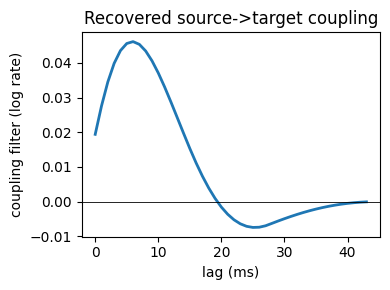

In [4]:
coupling_filter = np.asarray(full.get_filter()[1])   # effect 1 = source -> target coupling
integral = float(np.sum(coupling_filter))
df = full.predictors.shape[1] - nest.predictors.shape[1]
lrt_p = float(chi2.sf(2.0 * (nest.nll - full.nll), df))
print("Recovered source->target coupling integral: %.3f" % integral)
print("Likelihood-ratio test for coupling: p = %.3g (df=%d)" % (lrt_p, df))
print("==> Coupling detected" if lrt_p < 0.05 else "Coupling not detected")

plt.figure(figsize=(4,3))
plt.plot(coupling_filter, lw=2)
plt.axhline(0, color="k", lw=.6)
plt.xlabel("lag (ms)"); plt.ylabel("coupling filter (log rate)")
plt.title("Recovered source->target coupling"); plt.tight_layout(); plt.show()